# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import tkinter as tk
from tkinter import ttk

---

# Read in Excel file

In [2]:
df = pd.read_csv("processed-data/final_table.csv")
df.head()

,transaction_id,datetime,transaction_type,transaction_type_action,transaction_quantity,quantity_on_hand,medication_id,medication,hospital_id,hospital_name,hospital_ward_id,hospital_ward_name
0,1,2022-10-18 00:05:55,V,Event,0.0,46,997741,nadolol (CORGARD) 40mg tablet,2,St Joseph's,43,RX
1,2,2025-10-18 00:07:13,R,Return,-2.0,9,1025890,bisacodyl (DULCOLAX) 5mg tablet,2,St Joseph's,62,3P1
2,3,2022-10-18 00:07:18,I,Issue,1.0,13,1022831,meropenem Vial2Bag 500mg,2,St Joseph's,58,2NE
3,4,2022-10-18 00:07:30,I,Issue,1.0,2,1036923,fentaNYL 100mCg/2ml 2ml vial,2,St Joseph's,4,JOINT
4,5,2022-10-18 00:07:32,I,Issue,4.0,11,1038449,oxyCODONE IR 5mg tablet,2,St Joseph's,82,7TN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           1000 non-null   int64  
 1   datetime                 1000 non-null   object 
 2   transaction_type         1000 non-null   object 
 3   transaction_type_action  1000 non-null   object 
 4   transaction_quantity     1000 non-null   float64
 5   quantity_on_hand         1000 non-null   int64  
 6   medication_id            1000 non-null   int64  
 7   medication               1000 non-null   object 
 8   hospital_id              1000 non-null   int64  
 9   hospital_name            1000 non-null   object 
 10  hospital_ward_id         1000 non-null   int64  
 11  hospital_ward_name       1000 non-null   object 
dtypes: float64(1), int64(5), object(6)
memory usage: 93.9+ KB


---

# Exploratory data analysis

In [4]:
# Create a function to plot your figures
def plot_top_ten(data, column, shift):
    fig, ax = plt.subplots(figsize=(8,4), dpi=200)
    counts = data[column].value_counts()[:10].sort_values()
    counts.plot(kind='barh', ax=ax)
    
    # Add values on top of the bars
    for i, v in enumerate(counts):
        ax.text(v + shift, i, str(v), color='black', fontweight='bold')

### Most common medications in transactions

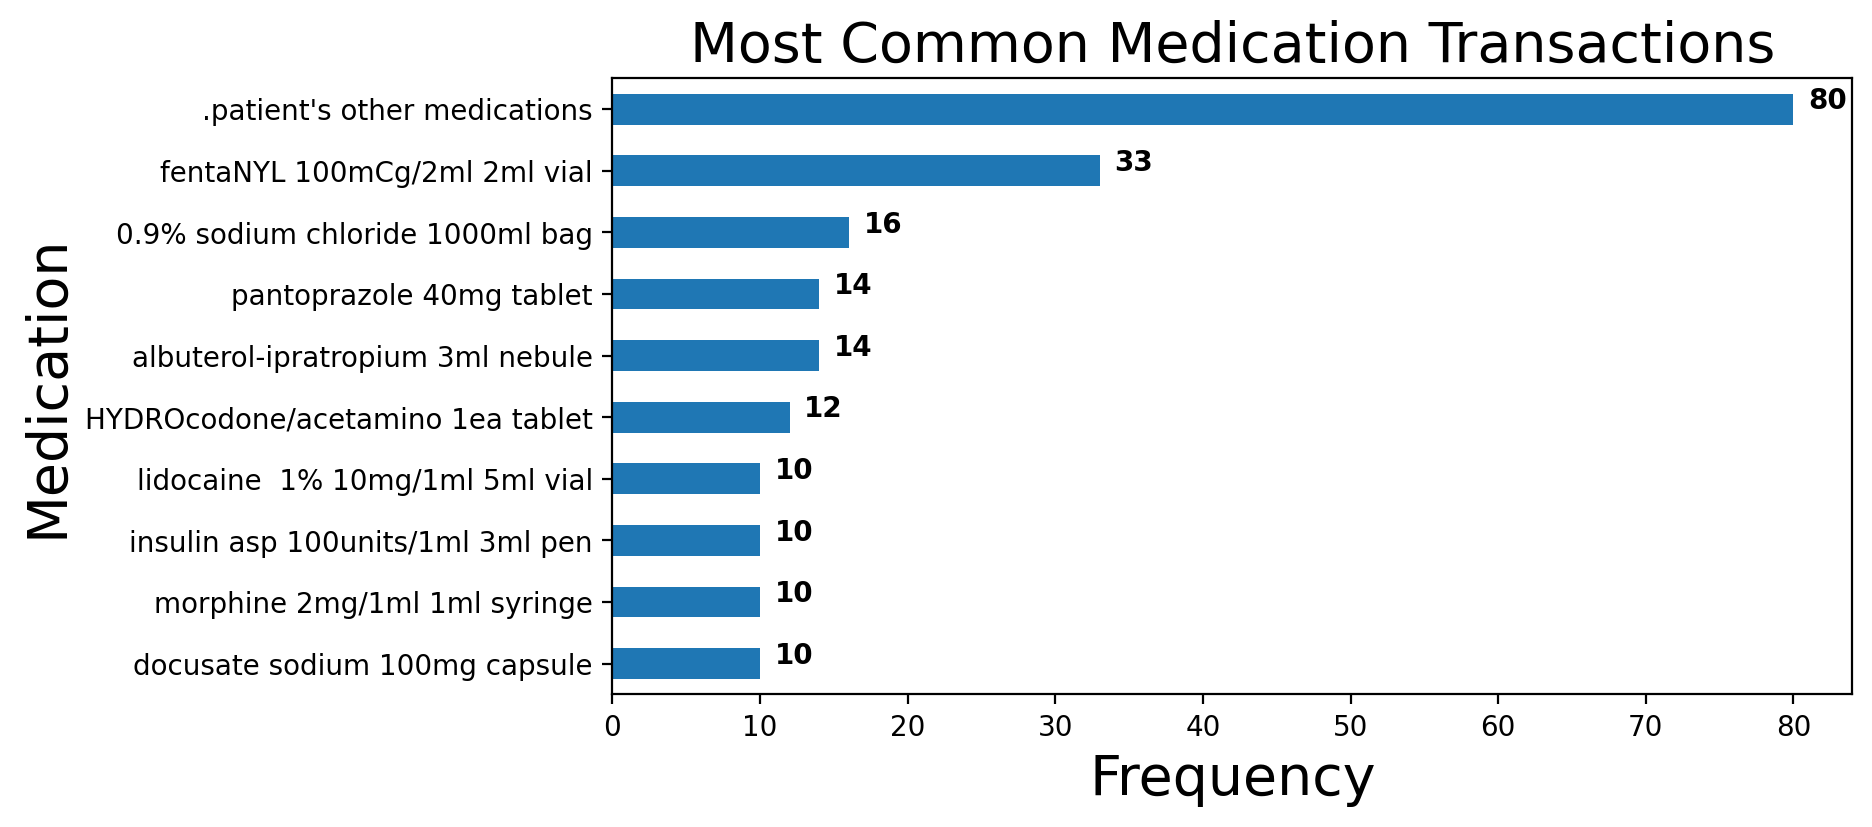

In [5]:
plot_top_ten(df, 'medication', 1)
plt.title('Most Common Medication Transactions', fontsize=20)
plt.xlabel('Frequency', fontsize=20)
plt.ylabel('Medication', fontsize=20);

#### There are 80 entries of '.patient's other medications' which is not a specific medication. How many unique medication ids make up this broad group?

In [6]:
df.loc[df['medication']=='.patient\'s other medications']['medication_id'].nunique()

20

#### Let's explore the second most common occuring medication: 'fentaNYL 100mCg/2ml 2ml vial'

In [7]:
df.loc[df['medication']=='fentaNYL 100mCg/2ml 2ml vial']['medication_id'].nunique()

28

In [8]:
print(f"Number of unique medications: {df['medication'].nunique()}")
print(f"Number of unique medication_id: {df['medication_id'].nunique()}")

Number of unique medications: 414
Number of unique medication_id: 820


#### It is evident that the medication_id is not unique to each medicine. This is a data collection problem. The only usefulness of the medication_id is thus to identify a medication during table joining.

### Most common wards in transactions

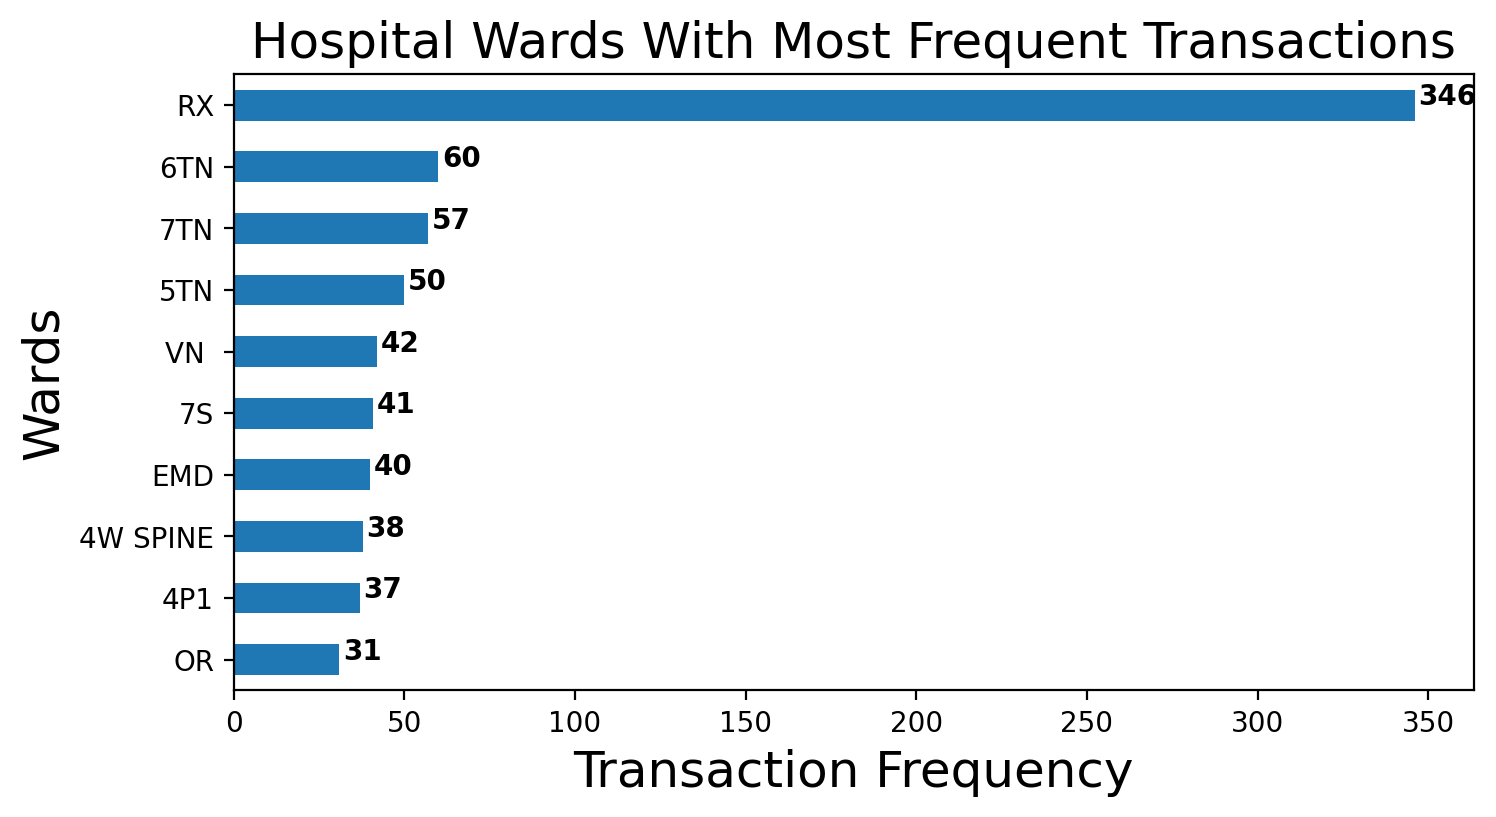

In [9]:
plot_top_ten(df, 'hospital_ward_name', 1)
plt.title('Hospital Wards With Most Frequent Transactions', fontsize=18)
plt.xlabel('Transaction Frequency', fontsize=18)
plt.ylabel('Wards', fontsize=18);

#### Most transactions occur in the RX ward

---

# User story

### What is the timeline of our data?

In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['datetime'].max() - df['datetime'].min()

Timedelta('20379 days 15:08:34')

In [11]:
df['datetime'].dt.year.unique()

array([2022, 2025, 1970], dtype=int32)

In [12]:
df.loc[df['datetime'].dt.year == 1970]

,transaction_id,datetime,transaction_type,transaction_type_action,transaction_quantity,quantity_on_hand,medication_id,medication,hospital_id,hospital_name,hospital_ward_id,hospital_ward_name
223,224,1970-01-01,D,Discrepancy,5.0,4,1016415,5% dextrose in water 100ml bag,2,St Joseph's,644799,OR_RX
736,737,1970-01-01,K,Destock,18.0,6,1032793,glycopyrrolat 0.2mg/1ml 1ml vial,2,St Joseph's,44,SDS


In [13]:
df.loc[df['datetime'].dt.year == 2025]

,transaction_id,datetime,transaction_type,transaction_type_action,transaction_quantity,quantity_on_hand,medication_id,medication,hospital_id,hospital_name,hospital_ward_id,hospital_ward_name
1,2,2025-10-18 00:07:13,R,Return,-2.0,9,1025890,bisacodyl (DULCOLAX) 5mg tablet,2,St Joseph's,62,3P1
380,381,2025-10-18 07:47:59,I,Issue,1.0,28,990520,thiamine (B-1) 100mg tablet,2,St Joseph's,32,VN
613,614,2025-10-18 08:40:18,I,Issue,1.0,50,990272,ipratro 0.5mg/2.5ml 2.5ml nebule,2,St Joseph's,64,4P1
716,717,2025-10-18 13:24:26,I,Issue,1.0,24,1041678,lidocaine 1% 10mg/1ml 5ml vial,2,St Joseph's,12,OR
952,953,2025-10-18 15:08:34,N,Null,0.0,0,1008626,"Aux 1, Zone 0",2,St Joseph's,644795,4W SPINE


### Rows with year 1970 do not have a time component. Furthermore, these rows are not useful to our user story because the transactions do not cause quantity on hand to be zero (0). Let's drop rows with year '1970'

In [14]:
df = df.drop(df.loc[df['datetime'].dt.year == 1970].index)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           998 non-null    int64         
 1   datetime                 998 non-null    datetime64[ns]
 2   transaction_type         998 non-null    object        
 3   transaction_type_action  998 non-null    object        
 4   transaction_quantity     998 non-null    float64       
 5   quantity_on_hand         998 non-null    int64         
 6   medication_id            998 non-null    int64         
 7   medication               998 non-null    object        
 8   hospital_id              998 non-null    int64         
 9   hospital_name            998 non-null    object        
 10  hospital_ward_id         998 non-null    int64         
 11  hospital_ward_name       998 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(5

### Let's change 2025 to 2022

In [15]:
df['datetime'] = pd.to_datetime(df['datetime'].dt.strftime('2022-%m-%d %H:%M:%S'))

df.head()

,transaction_id,datetime,transaction_type,transaction_type_action,transaction_quantity,quantity_on_hand,medication_id,medication,hospital_id,hospital_name,hospital_ward_id,hospital_ward_name
0,1,2022-10-18 00:05:55,V,Event,0.0,46,997741,nadolol (CORGARD) 40mg tablet,2,St Joseph's,43,RX
1,2,2022-10-18 00:07:13,R,Return,-2.0,9,1025890,bisacodyl (DULCOLAX) 5mg tablet,2,St Joseph's,62,3P1
2,3,2022-10-18 00:07:18,I,Issue,1.0,13,1022831,meropenem Vial2Bag 500mg,2,St Joseph's,58,2NE
3,4,2022-10-18 00:07:30,I,Issue,1.0,2,1036923,fentaNYL 100mCg/2ml 2ml vial,2,St Joseph's,4,JOINT
4,5,2022-10-18 00:07:32,I,Issue,4.0,11,1038449,oxyCODONE IR 5mg tablet,2,St Joseph's,82,7TN


In [16]:
df['datetime'].dt.year.unique()

array([2022], dtype=int32)

In [17]:
df['datetime'].max() - df['datetime'].min()

Timedelta('0 days 15:13:16')

### We have a timeline of approximately 15 hours

---

### Explore the transactions where quantity_on_hand = zero (0)

In [18]:
df_zero = df.loc[df['quantity_on_hand']==0]
df_zero

,transaction_id,datetime,transaction_type,transaction_type_action,transaction_quantity,quantity_on_hand,medication_id,medication,hospital_id,hospital_name,hospital_ward_id,hospital_ward_name
15,16,2022-10-18 01:59:24,R,Return,-1.00,0,1030764,LORazepam (ATIV 2mg/1ml 1ml vial,2,St Joseph's,58,2NE
30,31,2022-10-18 02:08:29,W,Waste,0.50,0,1036782,fentaNYL 100mCg/2ml 2ml vial,2,St Joseph's,36,EMD
31,32,2022-10-18 02:09:10,W,Waste,1.00,0,1036782,fentaNYL 100mCg/2ml 2ml vial,2,St Joseph's,36,EMD
33,34,2022-10-18 02:09:11,W,Waste,0.75,0,1020842,LORazepam (ATIV 2mg/1ml 1ml vial,2,St Joseph's,36,EMD
34,35,2022-10-18 02:09:12,N,Null,0.00,0,1008724,Main Zone 1,2,St Joseph's,43,RX
...,...,...,...,...,...,...,...,...,...,...,...,...
956,957,2022-10-18 15:08:39,V,Event,0.00,0,1022496,piperacillin/tazobactam (ZOSYN),2,St Joseph's,43,RX
957,958,2022-10-18 15:08:39,G,Pick,0.00,0,1022496,piperacillin/tazobactam (ZOSYN),2,St Joseph's,43,RX
974,975,2022-10-18 15:13:19,G,Pick,1.00,0,1037695,cefotaxime 1000mg vial,2,St Joseph's,43,RX
976,977,2022-10-18 15:13:19,V,Event,1.00,0,1037696,cefotaxime 1000mg vial,2,St Joseph's,43,RX


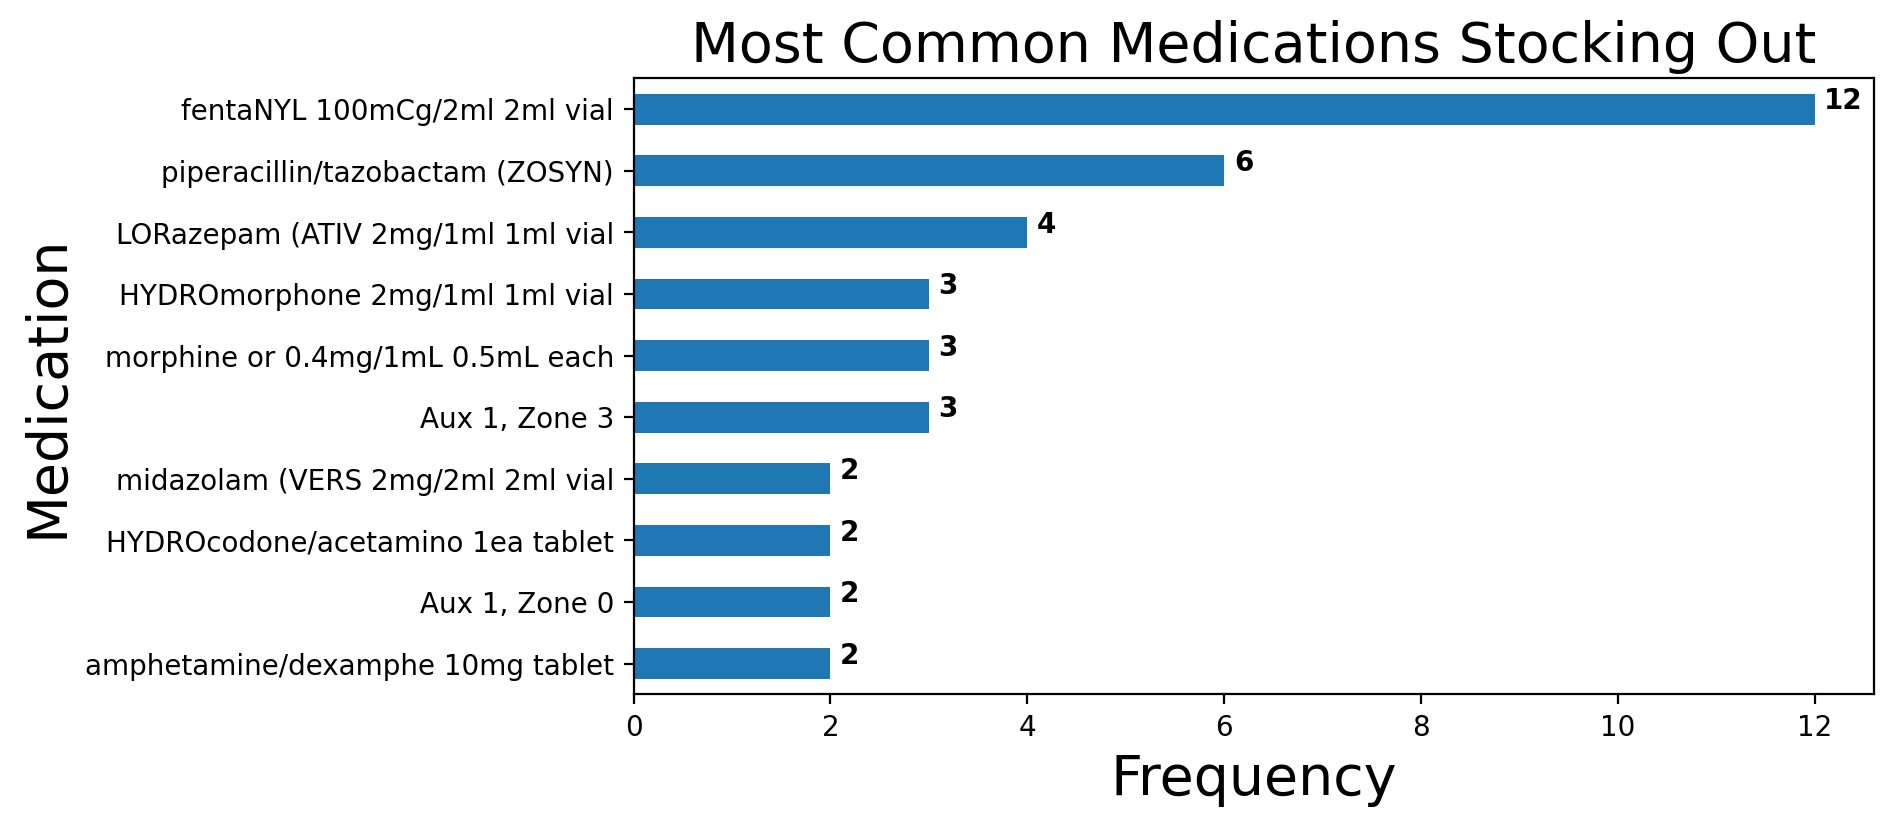

In [19]:
plot_top_ten(df_zero, 'medication', 0.1)
plt.title('Most Common Medications Stocking Out', fontsize=20)
plt.xlabel('Frequency', fontsize=20)
plt.ylabel('Medication', fontsize=20);

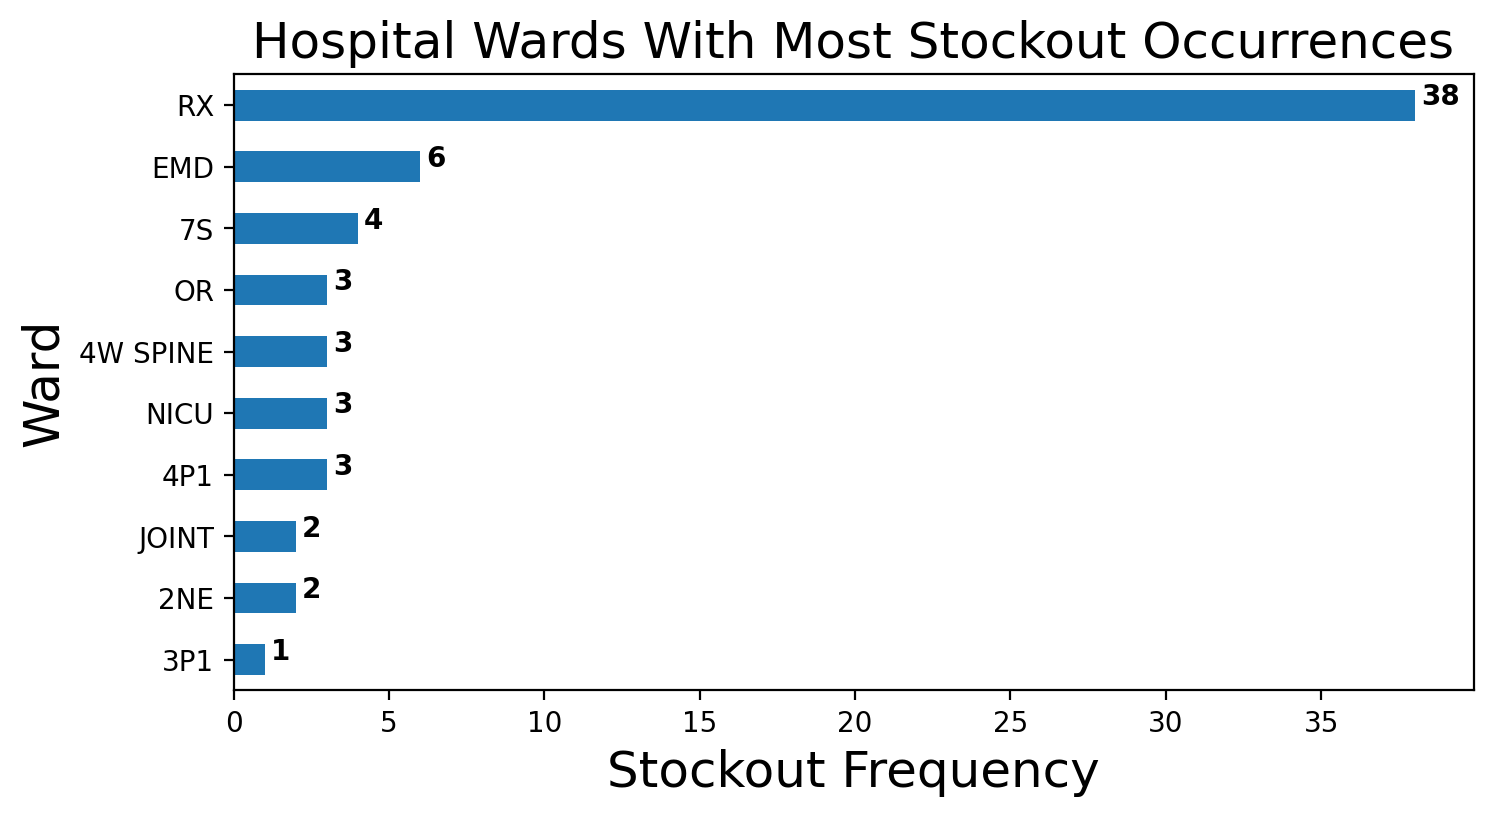

In [20]:
plot_top_ten(df_zero, 'hospital_ward_name', 0.2)
plt.title('Hospital Wards With Most Stockout Occurrences', fontsize=18)
plt.xlabel('Stockout Frequency', fontsize=18)
plt.ylabel('Ward', fontsize=18);

### It seems 'fentaNYL 100mCg/2ml 2ml vial' is medication stocking out the most and the most common ward experiencing stockout is the 'RX' ward. Is this really true though?

### We know from the data dictionary that situations in which the transaction quantity is negative means that medications were supplied to the machine rather than taken away from it. It really doesn't make sense for medications to be supplied to the dispensing cabinet and yet the quantity on hand remains zero. Let's explore this in some more depth

In [21]:
df_zero.loc[df['transaction_quantity']<0]

,transaction_id,datetime,transaction_type,transaction_type_action,transaction_quantity,quantity_on_hand,medication_id,medication,hospital_id,hospital_name,hospital_ward_id,hospital_ward_name
15,16,2022-10-18 01:59:24,R,Return,-1.0,0,1030764,LORazepam (ATIV 2mg/1ml 1ml vial,2,St Joseph's,58,2NE
138,139,2022-10-18 04:40:06,R,Return,-1.0,0,1039108,oxyCODONE IR 5mg tablet,2,St Joseph's,76,PREPOST
387,388,2022-10-18 07:48:48,L,Receive,-2.0,0,1035957,fosaprepitant 150mg/5ml 5ml vial,2,St Joseph's,43,RX
497,498,2022-10-18 08:19:54,L,Receive,-100.0,0,1038326,zolpidem 10mg tablet,2,St Joseph's,43,RX
498,499,2022-10-18 08:19:54,L,Receive,-1100.0,0,1039334,traMADol 50mg tablet,2,St Joseph's,43,RX
510,511,2022-10-18 08:27:26,L,Receive,-4.0,0,997552,hydrocortisone 1% crea 15gm tube,2,St Joseph's,43,RX
511,512,2022-10-18 08:27:26,L,Receive,-50.0,0,1027106,enoxapa 80mg/0.8ml 0.8ml syringe,2,St Joseph's,43,RX
512,513,2022-10-18 08:27:26,L,Receive,-4.0,0,1008505,caffeine citra 20mg/1ml 3ml vial,2,St Joseph's,43,RX
513,514,2022-10-18 08:27:26,L,Receive,-80.0,0,1038690,levETIRAcetam 100mg/1ml 5ml vial,2,St Joseph's,43,RX
514,515,2022-10-18 08:27:26,L,Receive,-6.0,0,990802,bss ophth irrigatio 500ml bottle,2,St Joseph's,43,RX


### Some data integrity questions need to be asked here.

### Again, from the data dictionary, we can tell that even if some transactions result in the quantity on hand of the medication being zero, depending on the transaction type, the situation cannot be logically regarded as stockout.
### Let's take a look at the unique transaction_type_action in the table

In [22]:
pd.DataFrame(df_zero['transaction_type_action'].unique(), index=df_zero['transaction_type'].unique())

,0
R,Return
W,Waste
N,Null
V,Event
G,Pick
I,Issue
K,Destock
X,Expired
L,Receive


### The decision on which transactions should count towards stockout is subjective and would likely require the input of a domain expert or clarification from the user. However, for this analysis, the following transaction types are regarded not to count towards an out of stock situation: Return, Waste, Null, Destock, Expired, and Receive

### The logic here is that these transaction types do not represent a situation where a medication was actually dispensed.

In [23]:
# Create a mask of the transaction_type_action to be excluded
mask_transaction_type = ~df_zero['transaction_type_action'].isin(['Return', 'Waste', 'Null', 
                                                                    'Destock', 'Expired', 'Receive'])
# The tilda (~) sign inverts the boolean series to return only rows not contained in the list

### Create final dataframe using the mask

In [24]:
df_stockout = df_zero[mask_transaction_type]
df_stockout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 38 to 993
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           29 non-null     int64         
 1   datetime                 29 non-null     datetime64[ns]
 2   transaction_type         29 non-null     object        
 3   transaction_type_action  29 non-null     object        
 4   transaction_quantity     29 non-null     float64       
 5   quantity_on_hand         29 non-null     int64         
 6   medication_id            29 non-null     int64         
 7   medication               29 non-null     object        
 8   hospital_id              29 non-null     int64         
 9   hospital_name            29 non-null     object        
 10  hospital_ward_id         29 non-null     int64         
 11  hospital_ward_name       29 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(5

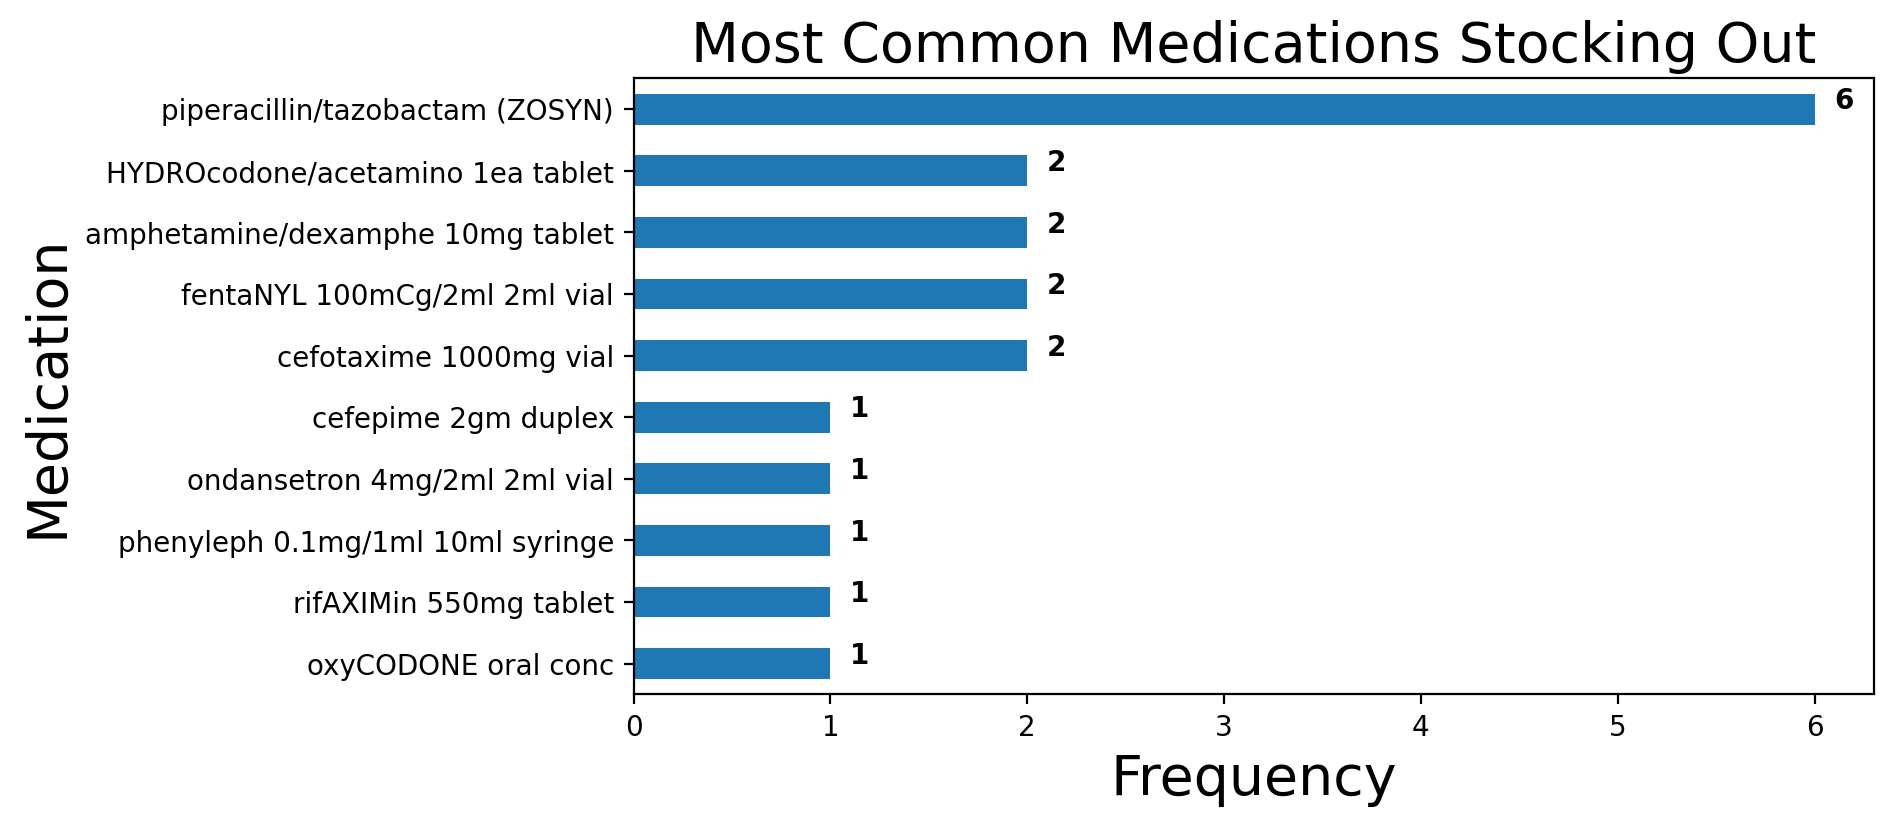

In [25]:
plot_top_ten(df_stockout, 'medication', 0.1)
plt.title('Most Common Medications Stocking Out', fontsize=20)
plt.xlabel('Frequency', fontsize=20)
plt.ylabel('Medication', fontsize=20);

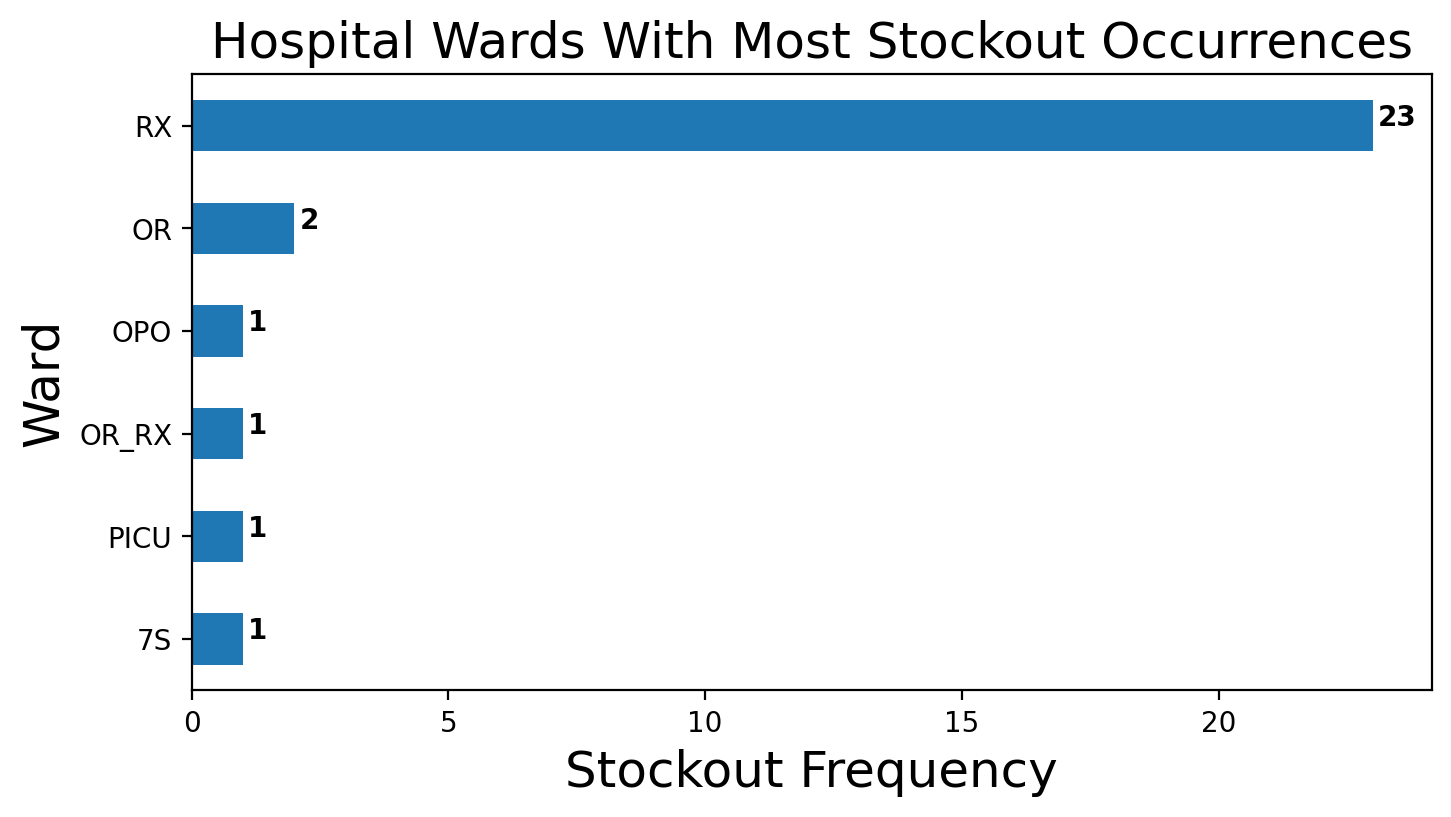

In [26]:
plot_top_ten(df_stockout, 'hospital_ward_name', 0.1)
plt.title('Hospital Wards With Most Stockout Occurrences', fontsize=18)
plt.xlabel('Stockout Frequency', fontsize=18)
plt.ylabel('Ward', fontsize=18);

### The charts above shows the top 10 drugs stocking out and the frequency of stockout in a 15-hour period. It also shows the wards in which these stockouts are occurring.

---

### Finally, which medications are stocking out by ward? Let's consider the top two wards with the most stockout occurences

In [27]:
# Create a new dataframe stockout_ward
stockout_ward = (
    df_stockout.groupby(['hospital_ward_name', 'medication'])['transaction_id'].count().reset_index(name='count')
                )
stockout_ward

,hospital_ward_name,medication,count
0,7S,fentaNYL 100mCg/2ml 2ml vial,1
1,OPO,ondansetron 4mg/2ml 2ml vial,1
2,OR,midazolam (VERS 2mg/2ml 2ml vial,1
3,OR,phenyleph 0.1mg/1ml 10ml syringe,1
4,OR_RX,b 100000units/500ml 500ml bottle,1
5,PICU,rsi/transport (pediatric 1ea box,1
6,RX,HYDROcodone/acetamino 1ea tablet,2
7,RX,HYDROmorphone 2mg/1ml 1ml vial,1
8,RX,amphetamine/dexamphe 10mg tablet,2
9,RX,cefepime 2gm duplex,1


### Which medications are stocking out in the RX ward and how frequent does this occur?

In [28]:
stockout_ward.loc[stockout_ward['hospital_ward_name']=='RX'].sort_values(by='count', ascending=False)

,hospital_ward_name,medication,count
19,RX,piperacillin/tazobactam (ZOSYN),6
6,RX,HYDROcodone/acetamino 1ea tablet,2
8,RX,amphetamine/dexamphe 10mg tablet,2
10,RX,cefotaxime 1000mg vial,2
7,RX,HYDROmorphone 2mg/1ml 1ml vial,1
9,RX,cefepime 2gm duplex,1
11,RX,fentaNYL 100mCg/2ml 2ml RFID,1
12,RX,fentaNYL 100mCg/2ml 2ml vial,1
13,RX,fentaNYL/bupi 3mcg/1ml 250ml bag,1
14,RX,ketamine (KET 50mg/1ml 10ml RFID,1


### Which medications are stocking out in the OR ward and how frequent does this occur?

In [29]:
stockout_ward.loc[stockout_ward['hospital_ward_name']=='OR'].sort_values(by='count')

,hospital_ward_name,medication,count
2,OR,midazolam (VERS 2mg/2ml 2ml vial,1
3,OR,phenyleph 0.1mg/1ml 10ml syringe,1


---

### While the visualizations above are good, what will be really helpful is to have a dynamic dashboard of some sort that can give all the information at a glance and can adapt to changing conditions of the table. The non-technical user can have an overview of medications stocking out, the ward in which they are stocking out, and also narrow down on which medications are stocking out per ward.

### The cell block below creates a dynamic graphical user interface that changes with the data supplied. 

In [30]:
# Create a function to display plots of medications stocking out and the wards in which they are stocking out
def stockout_calculator(table):
    # Create the table to be used by the class
    stockout_table = table.groupby(['hospital_ward_name', 'medication']
                                  )['transaction_id'].count().reset_index(name='count')
    
    # Create Stockout class
    class Stockout:
        
        # Initialize class attributes
        def __init__(self, root):
            self.root = root
            self.create_stockout_calculator_frame()
            self.create_medication_stockout_frame()
            self.create_ward_stockout_frame()
            
        def plot_figure(self, column):
            fig, ax = plt.subplots(figsize=(7,3.5), dpi=200)
            counts = table[column].value_counts()[:10].sort_values()
            counts.plot(kind='barh', ax=ax)

            # Add values on top of the bars
            for i, v in enumerate(counts):
                ax.text(v + 0.1, i, str(v), color='black', fontweight='bold')
            
        def create_medication_stockout_frame(self):
            """This function creates creates a barplot of medications stocking out"""
            self.plot_figure('medication')
            plt.title('Most Common Medications Stocking Out', fontsize=15)
            plt.xlabel('Frequency', fontsize=15)
            plt.ylabel('Medication', fontsize=15)
            medication_stockout_fig = plt.gcf()
            medication_stockout_fig.tight_layout()
            canvas = FigureCanvasTkAgg(medication_stockout_fig, master=self.root)
            canvas.draw()
            canvas.get_tk_widget().grid(row=0, column=0, sticky='ew', pady=2, padx=15)
            
        def create_ward_stockout_frame(self):
            """This function creates creates a barplot of the wards in which medications are stocking out"""
            self.plot_figure('hospital_ward_name')
            plt.title('Hospital Wards With Most Stockout Occurrences', fontsize=15)
            plt.xlabel('Stockout Frequency', fontsize=15)
            plt.ylabel('Ward', fontsize=15)
            ward_stockout_fig = plt.gcf()
            ward_stockout_fig.tight_layout()
            canvas = FigureCanvasTkAgg(ward_stockout_fig, master=self.root)
            canvas.draw()
            canvas.get_tk_widget().grid(row=1, column=0, sticky='ew', pady=2, padx=15)
            

        def create_stockout_calculator_frame(self):
            """This function creates the frame that contains the label, dropdown and the button to get the
            list of medication stocking out in a desired ward"""
            ward_stockout_frame = ttk.LabelFrame(self.root, text='Stockout by ward')
            ward_stockout_frame.grid(row=2, column=0, padx=8, pady=8, sticky='ew', columnspan=2)

            ttk.Label(ward_stockout_frame, text='Ward:').grid(row=0, column=0, sticky='ew', pady=2, padx=15)
            self.dropdown = ttk.Combobox(ward_stockout_frame, textvariable=tk.StringVar())
            self.dropdown['values'] = tuple(str(val) for val in stockout_table['hospital_ward_name'].unique())
            self.dropdown.grid(row=0, column=1, sticky='ew', padx=5, pady=2)

            ttk.Button(ward_stockout_frame, text='Find Stockout', 
                       command=self.create_table_in_new_window).grid(row=1, column=0, sticky='ew', padx=5, pady=5)

        def create_table_in_new_window(self):
            """This function returns a table that contains the medications stocking out in a desired ward and 
            how frequent they are stocking out"""
            self.transient = tk.Toplevel()
            self.transient.title('Medication Stockout by Ward')
            selected_value = str(self.dropdown.get())
            df_gui = stockout_table.loc[stockout_table['hospital_ward_name']==selected_value]
            df_gui = df_gui.sort_values(by='count', ascending=False)
            
            # Create a tree view
            columns = ('Ward', 'Medication', 'Stockout Count')
            tree = ttk.Treeview(self.transient, height=10, columns=columns, show='headings')
            tree.grid(row=0, columnspan=1, sticky='ew', padx=10)
            tree.heading('Ward', text='Ward', anchor='w')
            tree.heading("Medication", text='Medication', anchor='w')
            tree.heading("Stockout Count", text='Stockout Count', anchor='w')
            
            # Create scrollbar for the tree view
            scrollbar = ttk.Scrollbar(self.transient, orient='vertical', command=tree.yview)
            scrollbar.grid(row=0, column=1, rowspan=10, sticky='sn')
            
            # populate the tree with table items
            items = tree.get_children()
            for item in items:
                tree.delete(item)
            for row in df_gui.values:
                tree.insert('', 'end', values=(row[0], row[1], row[2]))
                                 
            self.transient.columnconfigure(0, weight=1)
            self.transient.rowconfigure(0, weight=1)
            self.transient.mainloop()
            
    root = tk.Tk()
    root.title('Medication Stockout')
    root.columnconfigure(0, weight=1)
    root.rowconfigure(0, weight=1)
    root.rowconfigure(1, weight=1)
    application = Stockout(root)
    root.mainloop()


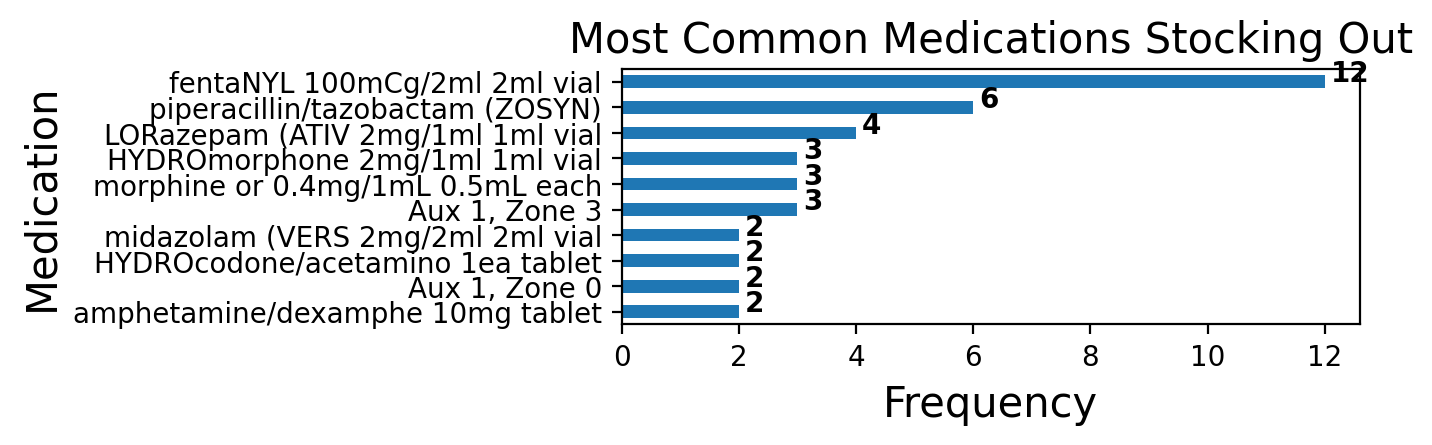

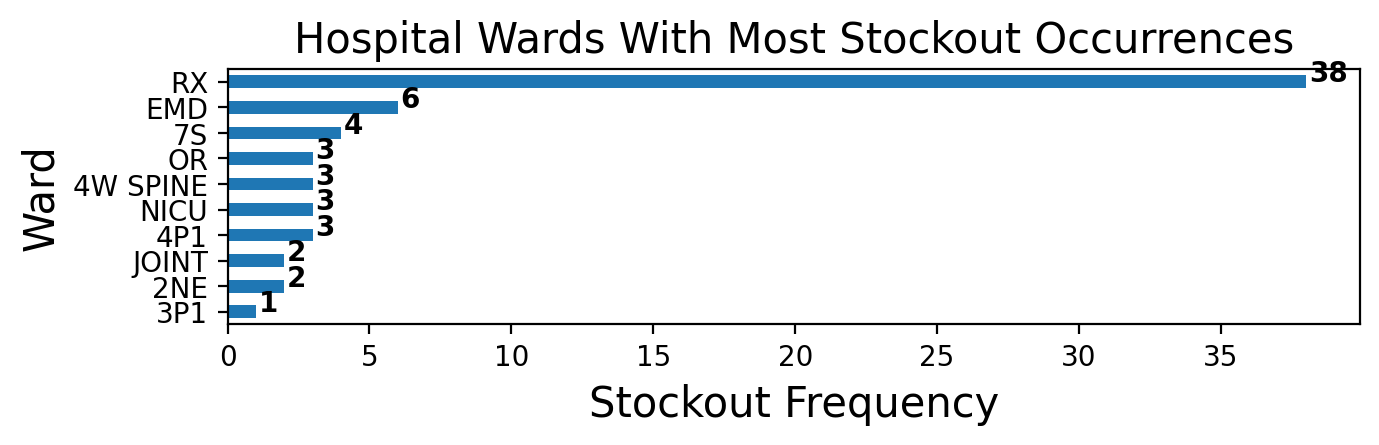

In [31]:
stockout_calculator(df_zero)